# codes for SVM

本 notebook 为 `ml_SVM_lec.ipynb` 生成模拟数据和配图。

**数据设计**：

| 数据集 | 样本量 | 说明 | 用途 |
|---|:---:|---|---|
| 数据集 A | 200 | 两类线性可分，特征空间二维 | 第一至三部分：最大间隔、软间隔、支持向量 |
| 数据集 B | 200 | 两类线性不可分（同心圆结构） | 第四部分：核技巧与 RBF 核 |

**图片命名规则**：`ml_SVM_fig{NN}_{描述}.png / .svg`

图片清单：

| 图号 | 文件名（不含扩展名） | 内容 |
|---|---|---|
| 01 | `ml_SVM_fig01_data_linear` | 数据集 A 散点图 |
| 02 | `ml_SVM_fig02_many_boundaries` | 多条可行分界线 |
| 03 | `ml_SVM_fig03_maxmargin` | 最大间隔分类器：最优超平面 + 间隔带 + 支持向量 |
| 04 | `ml_SVM_fig04_margin_geometry` | 间隔宽度 $2/||w||$ 的几何示意 |
| 05 | `ml_SVM_fig05_soft_margin_C` | 软间隔：不同 $C$ 值的决策边界对比 |
| 06 | `ml_SVM_fig06_support_vectors` | 普通点 vs 支持向量的稳定性对比 |
| 07 | `ml_SVM_fig07_data_nonlinear` | 数据集 B 散点图 + 线性边界失败 |
| 08 | `ml_SVM_fig08_kernel_idea` | 核技巧直觉：低维不可分 → 高维可分 |
| 09 | `ml_SVM_fig09_rbf_kernel` | 数据集 B 上 RBF 核 SVM 的非线性边界 |
| 10 | `ml_SVM_fig10_gamma_compare` | RBF 核不同 $\gamma$ 值的欠/适/过拟合对比 |
| 11 | `ml_SVM_fig11_C_gamma_heatmap` | 交叉验证 $C$-$\gamma$ 网格搜索热力图 |
| 12 | `ml_SVM_fig12_poly_kernel` | 多项式核 SVM 的决策边界 |
| 13 | `ml_SVM_fig13_svm_vs_logistic` | SVM 与 Logistic 回归决策边界对比 |


In [18]:
# ------------------------------------------------------------
# 0. 全局设置
# ------------------------------------------------------------

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.patches import FancyArrowPatch
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

os.makedirs('./figs', exist_ok=True)
os.makedirs('./data', exist_ok=True)

# ------------------------------------------------------------
# 中文字体设置
# ------------------------------------------------------------
available_fonts = {f.name for f in fm.fontManager.ttflist}
font_candidates = [
    'SimHei', 'Microsoft YaHei', 'Noto Sans CJK SC',
    'Noto Sans CJK JP', 'WenQuanYi Micro Hei',
    'Arial Unicode MS', 'DejaVu Sans',
]
FONT_FAMILY = next((f for f in font_candidates if f in available_fonts), 'DejaVu Sans')

plt.rcParams['font.sans-serif'] = [FONT_FAMILY]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.20,
    'figure.dpi': 150,
})

# 全局配色
C_BLUE   = '#1A3A6B'   # 深蓝，类别 -1
C_YELLOW = '#C8900A'   # 深黄，类别 +1
C_SV     = '#CC2222'   # 支持向量标注色
C_MARGIN = '#888888'   # 间隔带边界色

RNG = np.random.default_rng(2026)
print(f'当前使用字体: {FONT_FAMILY}')

当前使用字体: SimHei


In [2]:
# ------------------------------------------------------------
# 1. 生成数据集 A：线性可分
# ------------------------------------------------------------

def make_linear_data(n=200, seed=2026, margin_gap=1.8):
    '''
    生成线性可分的两类数据。
    真实决策边界：x2 = 0.8*x1（即 0.8*x1 - x2 = 0）。
    两类分别在边界两侧，间隔约为 margin_gap。
    '''
    rng = np.random.default_rng(seed)
    n_each = n // 2

    # 类别 -1（深蓝）：在边界下方
    x1_neg = rng.uniform(-3.5, 3.5, n_each)
    x2_neg = 0.8 * x1_neg - margin_gap / 2 - rng.exponential(0.6, n_each)

    # 类别 +1（深黄）：在边界上方
    x1_pos = rng.uniform(-3.5, 3.5, n_each)
    x2_pos = 0.8 * x1_pos + margin_gap / 2 + rng.exponential(0.6, n_each)

    X = np.vstack([np.c_[x1_neg, x2_neg], np.c_[x1_pos, x2_pos]])
    y = np.r_[np.full(n_each, -1), np.full(n_each, 1)]

    return X, y

X_A, y_A = make_linear_data(n=200)

# 保存
pd.DataFrame(np.c_[X_A, y_A], columns=['x1','x2','y']).to_csv(
    './data/svm_data_A_linear.csv', index=False, encoding='utf-8-sig')

print(f'数据集 A: {X_A.shape[0]} 条，类别分布: {dict(zip(*np.unique(y_A, return_counts=True)))}')
print(f'x1 范围: [{X_A[:,0].min():.2f}, {X_A[:,0].max():.2f}]')
print(f'x2 范围: [{X_A[:,1].min():.2f}, {X_A[:,1].max():.2f}]')

数据集 A: 200 条，类别分布: {np.int64(-1): np.int64(100), np.int64(1): np.int64(100)}
x1 范围: [-3.49, 3.50]
x2 范围: [-5.73, 5.99]


In [3]:
# ------------------------------------------------------------
# 2. 生成数据集 B：非线性可分（同心圆）
# ------------------------------------------------------------

def make_nonlinear_data(n=200, seed=42, noise=0.25):
    '''
    生成同心圆结构的两类数据。
    类别 -1（深蓝）：内圆，半径约 1；
    类别 +1（深黄）：外环，半径约 2.3。
    '''
    rng = np.random.default_rng(seed)
    n_each = n // 2

    # 内圆：类别 -1
    r_inner = rng.uniform(0.3, 1.2, n_each)
    theta_inner = rng.uniform(0, 2 * np.pi, n_each)
    x1_neg = r_inner * np.cos(theta_inner) + rng.normal(0, noise, n_each)
    x2_neg = r_inner * np.sin(theta_inner) + rng.normal(0, noise, n_each)

    # 外环：类别 +1
    r_outer = rng.uniform(2.0, 3.2, n_each)
    theta_outer = rng.uniform(0, 2 * np.pi, n_each)
    x1_pos = r_outer * np.cos(theta_outer) + rng.normal(0, noise, n_each)
    x2_pos = r_outer * np.sin(theta_outer) + rng.normal(0, noise, n_each)

    X = np.vstack([np.c_[x1_neg, x2_neg], np.c_[x1_pos, x2_pos]])
    y = np.r_[np.full(n_each, -1), np.full(n_each, 1)]

    return X, y

X_B, y_B = make_nonlinear_data(n=200)

pd.DataFrame(np.c_[X_B, y_B], columns=['x1','x2','y']).to_csv(
    './data/svm_data_B_nonlinear.csv', index=False, encoding='utf-8-sig')

print(f'数据集 B: {X_B.shape[0]} 条，类别分布: {dict(zip(*np.unique(y_B, return_counts=True)))}')

数据集 B: 200 条，类别分布: {np.int64(-1): np.int64(100), np.int64(1): np.int64(100)}


In [4]:
# ------------------------------------------------------------
# 3. 辅助函数
# ------------------------------------------------------------

def plot_scatter(ax, X, y, alpha=0.75, s=38, zorder=3):
    '''绘制两类散点，深蓝/深黄配色。'''
    for val, color, marker, label in [
        (-1, C_BLUE,   'o', '类别 $-1$'),
        ( 1, C_YELLOW, 's', '类别 $+1$'),
    ]:
        mask = y == val
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=color, marker=marker, s=s, alpha=alpha,
                   edgecolors='white', linewidths=0.4,
                   label=label, zorder=zorder)


def plot_decision_boundary(ax, clf, X, resolution=300,
                            draw_margin=True, cmap_bg=True):
    '''
    绘制 SVC 的决策边界和间隔带。
    - 实线：决策边界 f(x)=0
    - 虚线：间隔边界 f(x)=±1
    - 背景色块：两类的预测区域
    '''
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    if cmap_bg:
        bg_cmap = ListedColormap(['#D6E4F7', '#FFF3CC'])
        ax.contourf(xx, yy, Z, levels=[-999, 0, 999],
                    cmap=bg_cmap, alpha=0.35, zorder=0)

    # 决策边界
    ax.contour(xx, yy, Z, levels=[0],
               colors='#333333', linewidths=2.0, zorder=2)
    if draw_margin:
        ax.contour(xx, yy, Z, levels=[-1, 1],
                   colors=C_MARGIN, linewidths=1.2,
                   linestyles='--', zorder=2)


def mark_support_vectors(ax, clf, s=120):
    '''用红色空心圆圈标注支持向量。'''
    sv = clf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1],
               s=s, facecolors='none', edgecolors=C_SV,
               linewidths=1.8, zorder=5, label='支持向量')


def save_fig(fig, basename):
    '''统一保存 PNG 和 SVG。'''
    fig.savefig(f'./figs/{basename}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'./figs/{basename}.svg', bbox_inches='tight')

print('辅助函数定义完毕')

辅助函数定义完毕


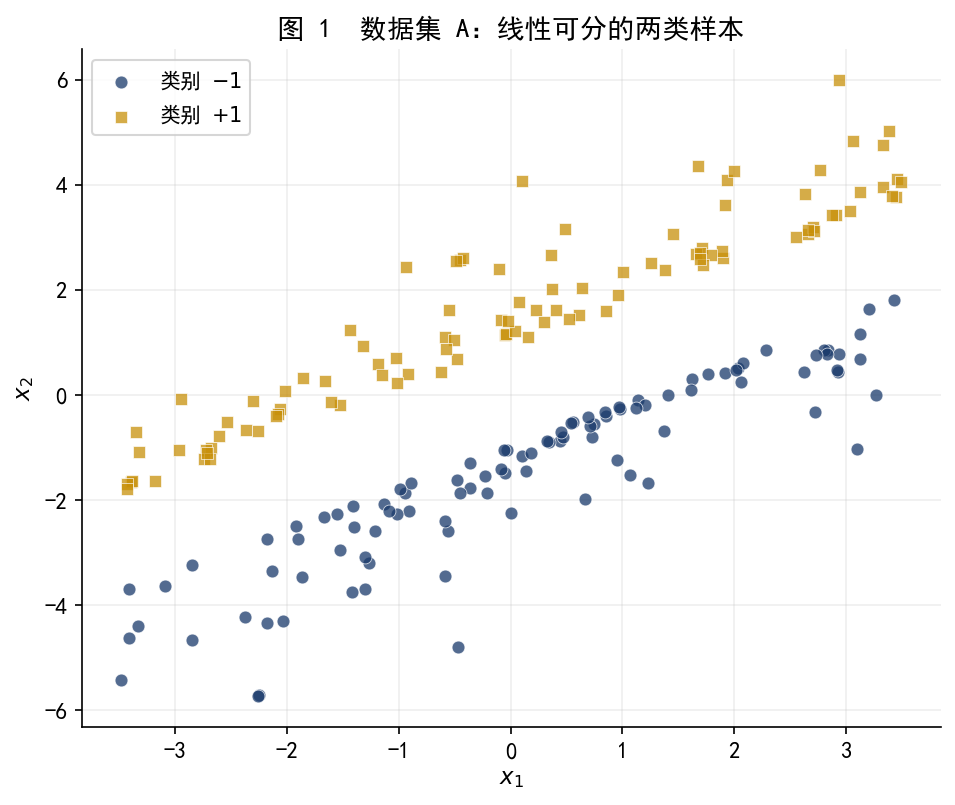

In [5]:
# ------------------------------------------------------------
# 图 01：数据集 A 散点图
# ml_SVM_fig01_data_linear
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_scatter(ax, X_A, y_A)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('图 1  数据集 A：线性可分的两类样本')
ax.legend(fontsize=10, loc='upper left')
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig01_data_linear')
plt.show()

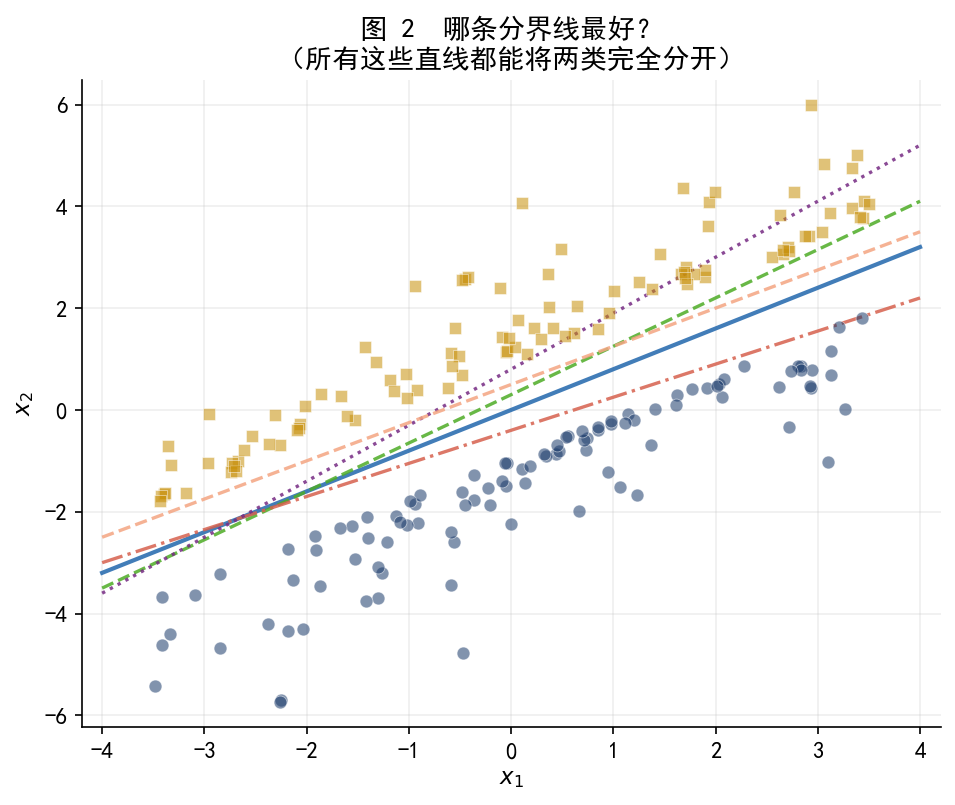

In [6]:
# ------------------------------------------------------------
# 图 02：多条可行分界线
# ml_SVM_fig02_many_boundaries
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_scatter(ax, X_A, y_A, alpha=0.55)

x_line = np.linspace(-4, 4, 200)

# 画 5 条都能（大致）分开两类的直线
lines = [
    (0.80,  0.0,  '#2166AC', '-',  2.0, ''),
    (0.95,  0.3,  '#4DAC26', '--', 1.6, ''),
    (0.65, -0.4,  '#D6604D', '-.',  1.6, ''),
    (1.10,  0.8,  '#762A83', ':',  1.6, ''),
    (0.75,  0.5,  '#F4A582', '--', 1.6, ''),
]
for slope, intercept, color, ls, lw, label in lines:
    ax.plot(x_line, slope * x_line + intercept,
            color=color, linestyle=ls, linewidth=lw, alpha=0.85)

ax.set_xlim(-4.2, 4.2)
ax.set_ylim(X_A[:,1].min()-0.5, X_A[:,1].max()+0.5)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('图 2  哪条分界线最好？\n（所有这些直线都能将两类完全分开）')
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig02_many_boundaries')
plt.show()

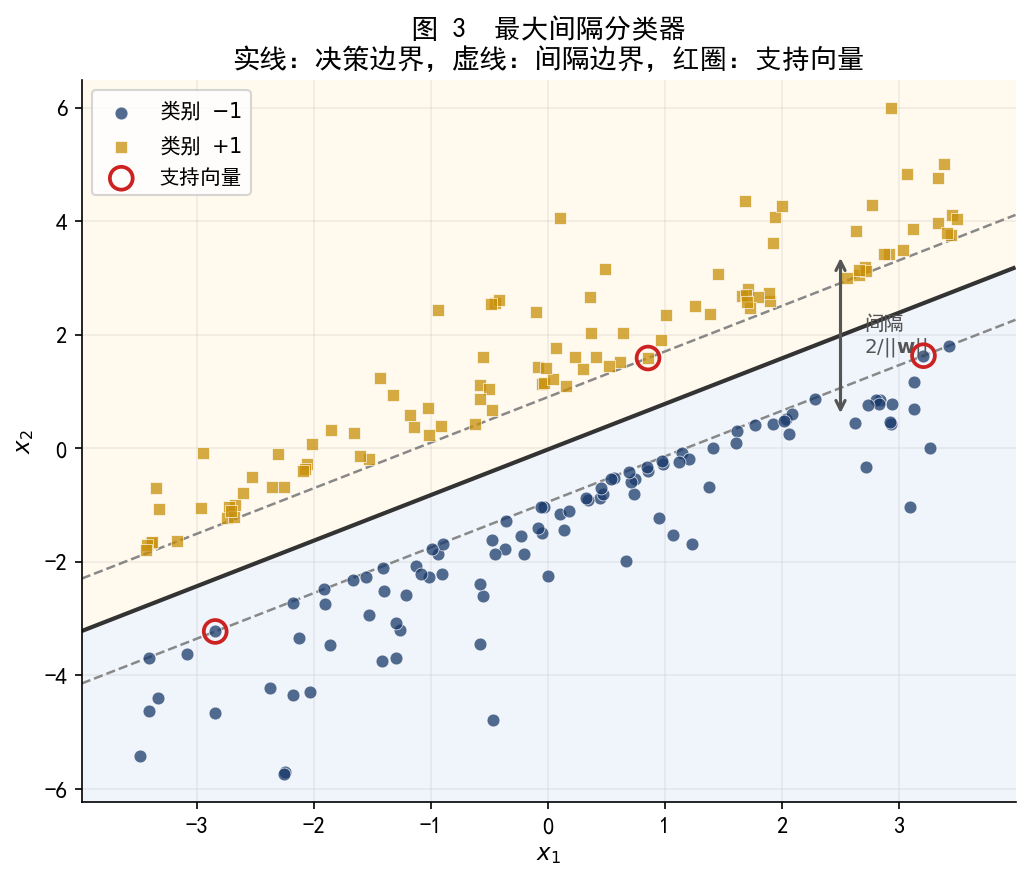

支持向量数量: 3
w = [-0.86875758  1.08265815], b = 0.0190
间隔宽度 = 1.4408


In [7]:
# ------------------------------------------------------------
# 图 03：最大间隔分类器
# ml_SVM_fig03_maxmargin
# ------------------------------------------------------------

# 用硬间隔 SVM（C 极大）拟合
svm_hard = SVC(kernel='linear', C=1e6)
svm_hard.fit(X_A, y_A)

fig, ax = plt.subplots(figsize=(7, 6))

# 背景色 + 决策边界
plot_decision_boundary(ax, svm_hard, X_A, draw_margin=True)
plot_scatter(ax, X_A, y_A)
mark_support_vectors(ax, svm_hard)

# 标注间隔带文字
w = svm_hard.coef_[0]
b = svm_hard.intercept_[0]
# 在图中间偏右位置标注 '间隔带'
ax.annotate('', xy=(2.5, -w[0]/w[1]*2.5 - b/w[1] + 1.0/np.linalg.norm(w)*2),
            xytext=(2.5, -w[0]/w[1]*2.5 - b/w[1] - 1.0/np.linalg.norm(w)*2),
            arrowprops=dict(arrowstyle='<->', color='#555555', lw=1.5))
ax.text(2.7, -w[0]/w[1]*2.5 - b/w[1],
        f'间隔\n$2/||\mathbf{{w}}||$',
        fontsize=9.5, color='#555555', va='center')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('图 3  最大间隔分类器\n实线：决策边界，虚线：间隔边界，红圈：支持向量')
ax.legend(fontsize=10, loc='upper left')
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig03_maxmargin')
plt.show()

print(f'支持向量数量: {svm_hard.support_vectors_.shape[0]}')
print(f'w = {w}, b = {b:.4f}')
print(f'间隔宽度 = {2 / np.linalg.norm(w):.4f}')

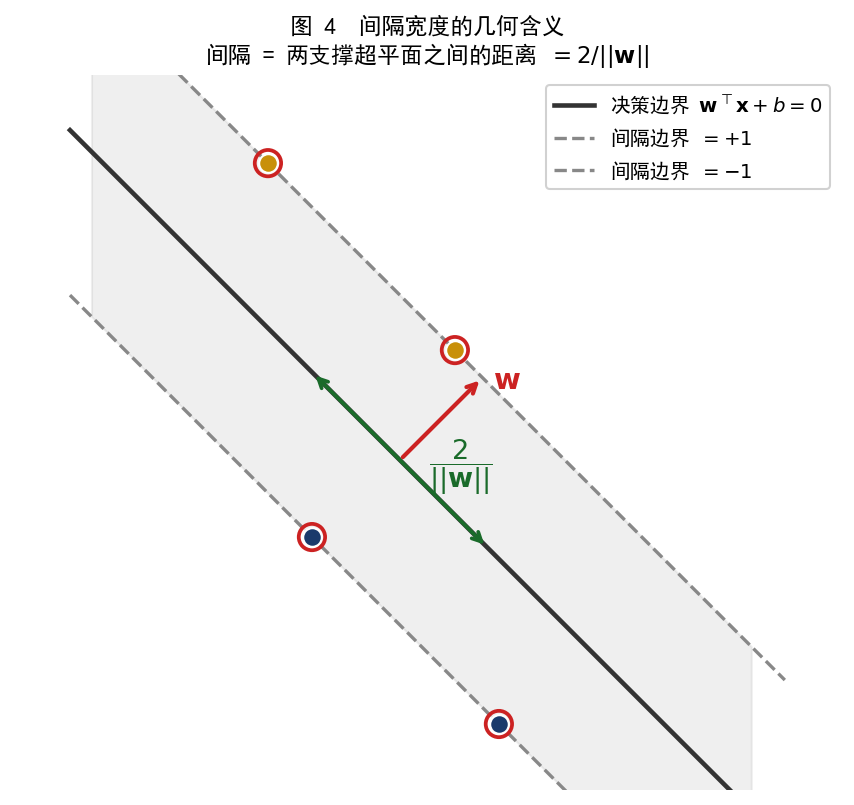

In [8]:
# ------------------------------------------------------------
# 图 04：间隔宽度的几何示意
# ml_SVM_fig04_margin_geometry
# 手绘风格，展示三条平行超平面和法向量
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.set_xlim(-3.5, 4.0)
ax.set_ylim(-3.0, 3.5)
ax.set_aspect('equal')
ax.axis('off')

# 超平面参数：w·x + b = 0，取 w=(1,1)/sqrt(2), b=0 方便画图
# x2 = -x1 方向
slope = -1.0
x_line = np.linspace(-3, 3.5, 300)

# 三条超平面
ax.plot(x_line, slope * x_line,       color='#333333', lw=2.2,  label='决策边界 $\mathbf{w}^\\top\mathbf{x}+b=0$')
ax.plot(x_line, slope * x_line + 1.5, color=C_MARGIN,  lw=1.6, linestyle='--', label='间隔边界 $= +1$')
ax.plot(x_line, slope * x_line - 1.5, color=C_MARGIN,  lw=1.6, linestyle='--', label='间隔边界 $= -1$')

# 填充间隔带
x_fill = np.linspace(-2.8, 3.2, 300)
ax.fill_between(x_fill, slope*x_fill-1.5, slope*x_fill+1.5,
                alpha=0.12, color='gray')

# 法向量 w
ax.annotate('', xy=(0.75, 0.75), xytext=(0.0, 0.0),
            arrowprops=dict(arrowstyle='->', color='#CC2222', lw=2.0))
ax.text(0.85, 0.65, '$\mathbf{w}$', fontsize=14, color='#CC2222')

# 标注间隔宽度
# 从 (0, 0) 沿法向量方向到间隔边界的距离
ax.annotate('', xy=(0.53*1.5, -0.53*1.5), xytext=(-0.53*1.5, 0.53*1.5),
            arrowprops=dict(arrowstyle='<->', color='#1A6B2A', lw=1.8))
ax.text(0.55, -0.1, '$\\dfrac{2}{||\mathbf{w}||}$',
        fontsize=13, color='#1A6B2A', ha='center')

# 散几个示意点
sv_pts = np.array([[-1.2, 1.2+1.5], [0.5, -0.5+1.5],
                   [-0.8, 0.8-1.5], [0.9, -0.9-1.5]])
ax.scatter(sv_pts[:2,0], sv_pts[:2,1], c=C_YELLOW, s=80,
           edgecolors='white', zorder=5)
ax.scatter(sv_pts[2:,0], sv_pts[2:,1], c=C_BLUE, s=80,
           edgecolors='white', zorder=5)
# 红圈标支持向量
ax.scatter(sv_pts[:,0], sv_pts[:,1], s=160, facecolors='none',
           edgecolors=C_SV, linewidths=1.8, zorder=6)

ax.legend(fontsize=9.5, loc='upper right', framealpha=0.9)
ax.set_title('图 4  间隔宽度的几何含义\n间隔 = 两支撑超平面之间的距离 $= 2/||\mathbf{w}||$',
             fontsize=11)
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig04_margin_geometry')
plt.show()

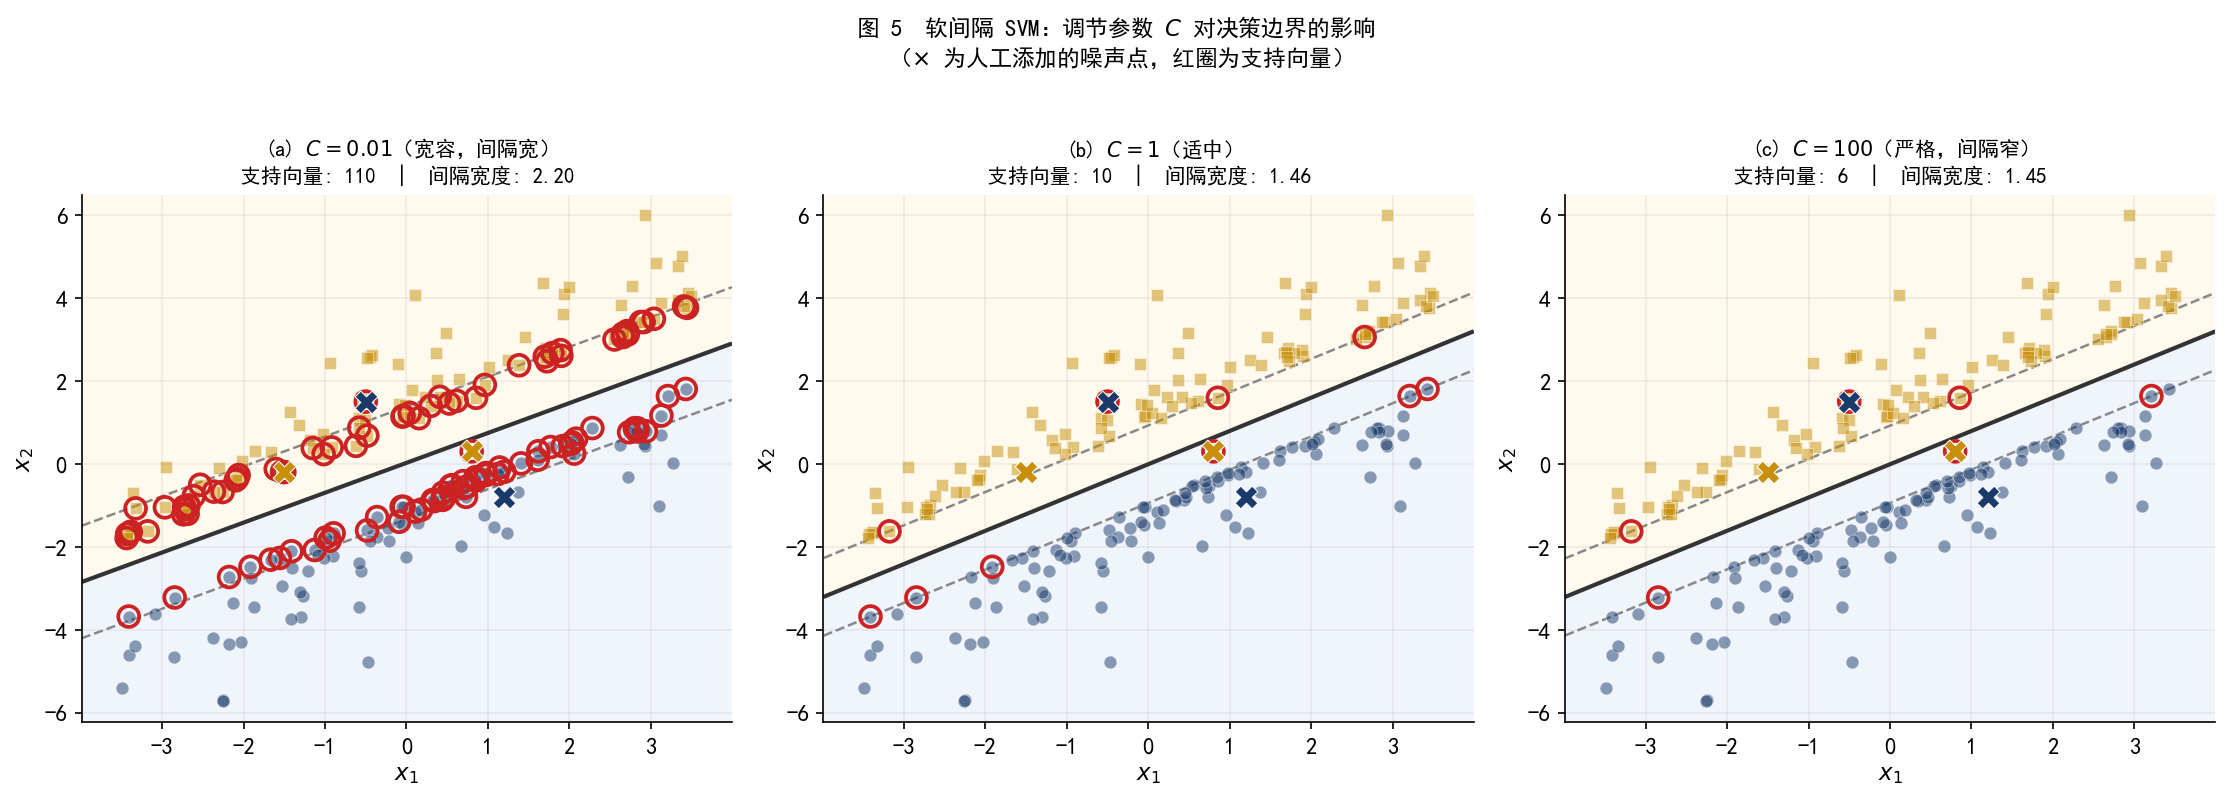

In [9]:
# ------------------------------------------------------------
# 图 05：软间隔 SVM，不同 C 值的决策边界
# ml_SVM_fig05_soft_margin_C
# ------------------------------------------------------------

# 在数据集 A 中加入少量噪声点（使软间隔效果明显）
rng_noise = np.random.default_rng(999)
noise_pts = np.array([
    [-1.5, -0.2],  # 深蓝区域里的深黄点
    [ 0.8,  0.3],
    [ 1.2, -0.8],  # 深黄区域里的深蓝点
    [-0.5,  1.5],
])
noise_labels = np.array([1, 1, -1, -1])

X_A2 = np.vstack([X_A, noise_pts])
y_A2 = np.r_[y_A, noise_labels]

C_vals = [0.01, 1.0, 100.0]
titles = [
    '(a) $C = 0.01$（宽容，间隔宽）',
    '(b) $C = 1$（适中）',
    '(c) $C = 100$（严格，间隔窄）',
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))

for ax, C_val, title in zip(axes, C_vals, titles):
    clf = SVC(kernel='linear', C=C_val)
    clf.fit(X_A2, y_A2)

    plot_decision_boundary(ax, clf, X_A2, draw_margin=True)
    plot_scatter(ax, X_A, y_A, alpha=0.5)          # 原始点
    # 标出噪声点（用 X 标记）
    for pt, lab in zip(noise_pts, noise_labels):
        color = C_YELLOW if lab == 1 else C_BLUE
        ax.scatter(*pt, c=color, marker='X', s=120,
                   edgecolors='white', linewidths=0.5,
                   zorder=6)
    mark_support_vectors(ax, clf, s=100)

    n_sv = clf.support_vectors_.shape[0]
    margin = 2 / np.linalg.norm(clf.coef_)
    ax.set_title(f'{title}\n支持向量: {n_sv}  |  间隔宽度: {margin:.2f}',
                 fontsize=10)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

fig.suptitle('图 5  软间隔 SVM：调节参数 $C$ 对决策边界的影响\n'
             '（$\\times$ 为人工添加的噪声点，红圈为支持向量）',
             fontsize=11, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig05_soft_margin_C')
plt.show()

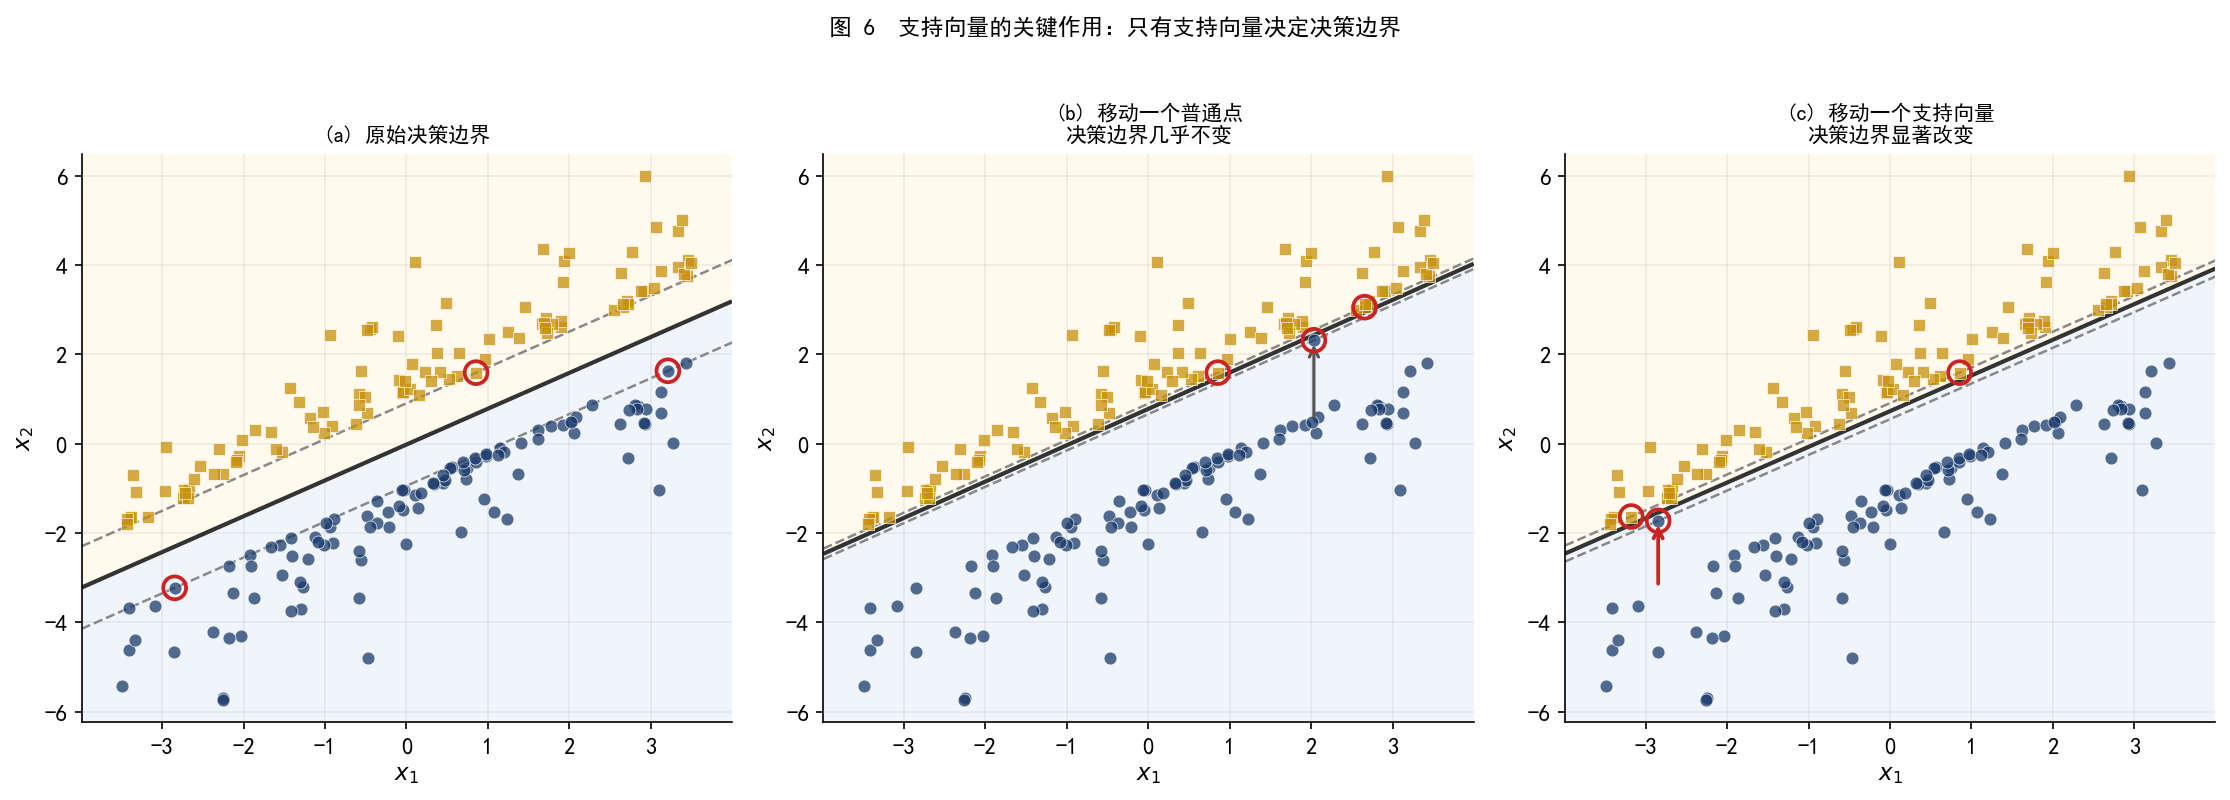

In [10]:
# ------------------------------------------------------------
# 图 06：普通点 vs 支持向量的稳定性对比
# ml_SVM_fig06_support_vectors
# ------------------------------------------------------------

svm_base = SVC(kernel='linear', C=1e6)
svm_base.fit(X_A, y_A)
sv_indices = svm_base.support_

# 找一个非支持向量的点（深蓝类）
non_sv_mask = np.ones(len(X_A), dtype=bool)
non_sv_mask[sv_indices] = False
non_sv_blue = np.where(non_sv_mask & (y_A == -1))[0]
move_idx_ordinary = non_sv_blue[5]   # 选一个普通点
move_idx_sv = sv_indices[0]           # 选一个支持向量

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))

# --- 子图 (a): 原始边界 ---
ax = axes[0]
plot_decision_boundary(ax, svm_base, X_A)
plot_scatter(ax, X_A, y_A)
mark_support_vectors(ax, svm_base)
ax.set_title('(a) 原始决策边界', fontsize=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# --- 子图 (b): 移动普通点 ---
ax = axes[1]
X_moved_ordinary = X_A.copy()
old_pt = X_A[move_idx_ordinary].copy()
X_moved_ordinary[move_idx_ordinary] += np.array([0.0, 1.8])  # 向上移动
svm_ord = SVC(kernel='linear', C=1e6)
svm_ord.fit(X_moved_ordinary, y_A)
plot_decision_boundary(ax, svm_ord, X_moved_ordinary)
plot_scatter(ax, X_moved_ordinary, y_A)
mark_support_vectors(ax, svm_ord)
# 标出移动的点
ax.annotate('', xy=X_moved_ordinary[move_idx_ordinary],
            xytext=old_pt,
            arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))
ax.set_title('(b) 移动一个普通点\n决策边界几乎不变', fontsize=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# --- 子图 (c): 移动支持向量 ---
ax = axes[2]
X_moved_sv = X_A.copy()
old_sv = X_A[move_idx_sv].copy()
X_moved_sv[move_idx_sv] += np.array([0.0, 1.5])
svm_sv = SVC(kernel='linear', C=1e6)
svm_sv.fit(X_moved_sv, y_A)
plot_decision_boundary(ax, svm_sv, X_moved_sv)
plot_scatter(ax, X_moved_sv, y_A)
mark_support_vectors(ax, svm_sv)
ax.annotate('', xy=X_moved_sv[move_idx_sv],
            xytext=old_sv,
            arrowprops=dict(arrowstyle='->', color=C_SV, lw=1.8))
ax.set_title('(c) 移动一个支持向量\n决策边界显著改变', fontsize=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

fig.suptitle('图 6  支持向量的关键作用：只有支持向量决定决策边界',
             fontsize=11, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig06_support_vectors')
plt.show()

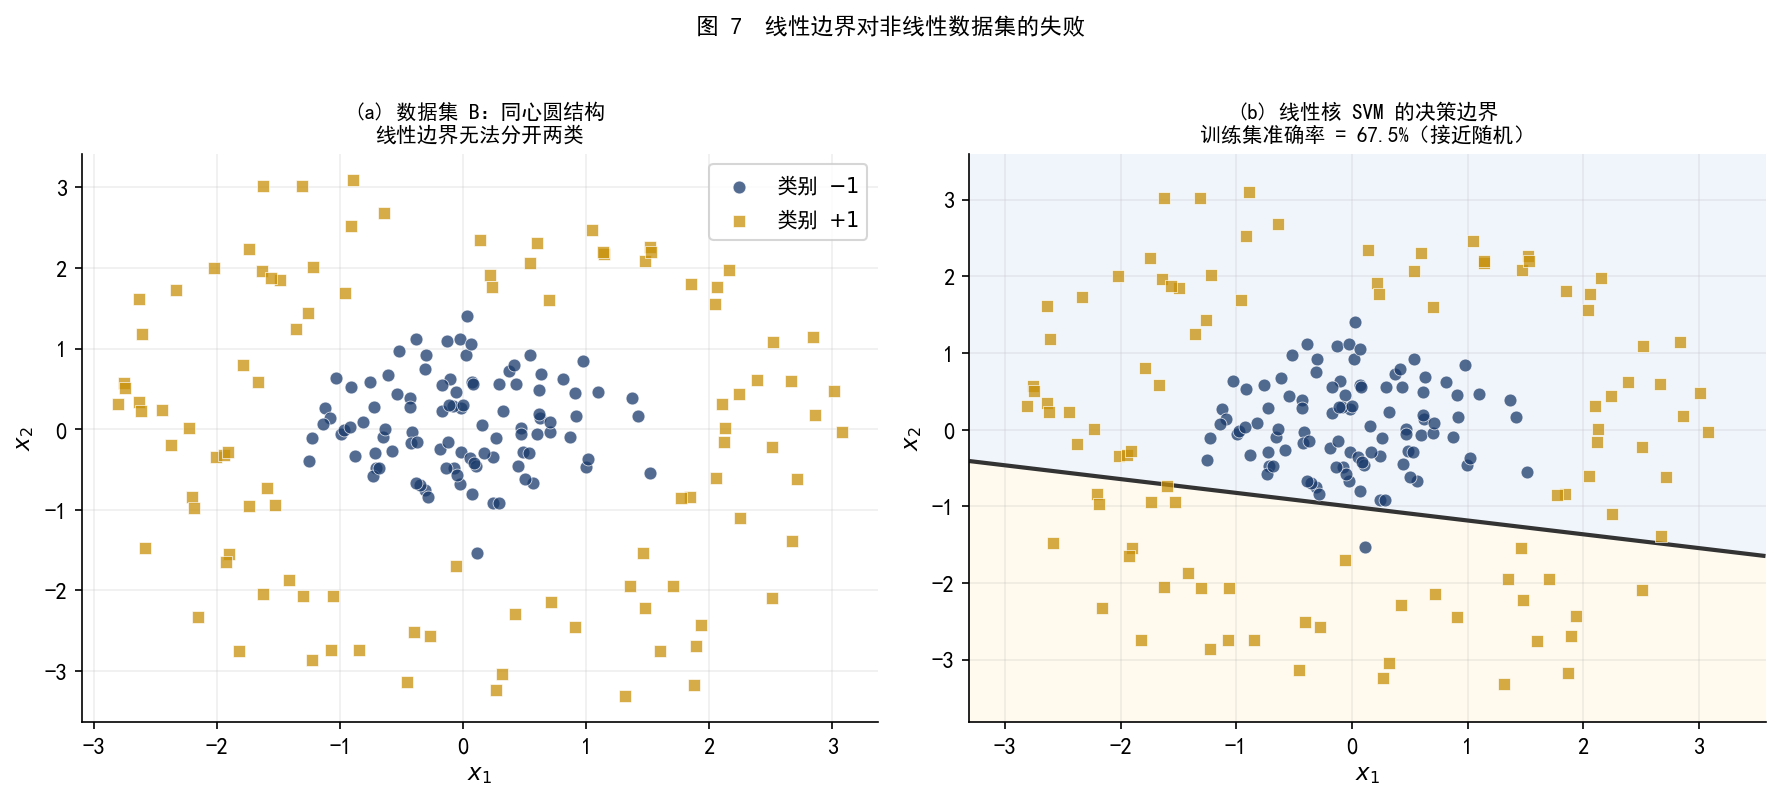

线性 SVM 训练集准确率: 0.6750


In [11]:
# ------------------------------------------------------------
# 图 07：数据集 B 散点图 + 线性 SVM 的失败
# ml_SVM_fig07_data_nonlinear
# ------------------------------------------------------------

svm_linear_B = SVC(kernel='linear', C=1.0)
svm_linear_B.fit(X_B, y_B)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# 左：仅散点图
ax = axes[0]
plot_scatter(ax, X_B, y_B)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('(a) 数据集 B：同心圆结构\n线性边界无法分开两类', fontsize=10)
ax.legend(fontsize=10)

# 右：线性 SVM（效果差）
ax = axes[1]
plot_decision_boundary(ax, svm_linear_B, X_B, draw_margin=False)
plot_scatter(ax, X_B, y_B)
acc_linear = (svm_linear_B.predict(X_B) == y_B).mean()
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(f'(b) 线性核 SVM 的决策边界\n训练集准确率 = {acc_linear:.1%}（接近随机）',
             fontsize=10)

fig.suptitle('图 7  线性边界对非线性数据集的失败', fontsize=11, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig07_data_nonlinear')
plt.show()
print(f'线性 SVM 训练集准确率: {acc_linear:.4f}')

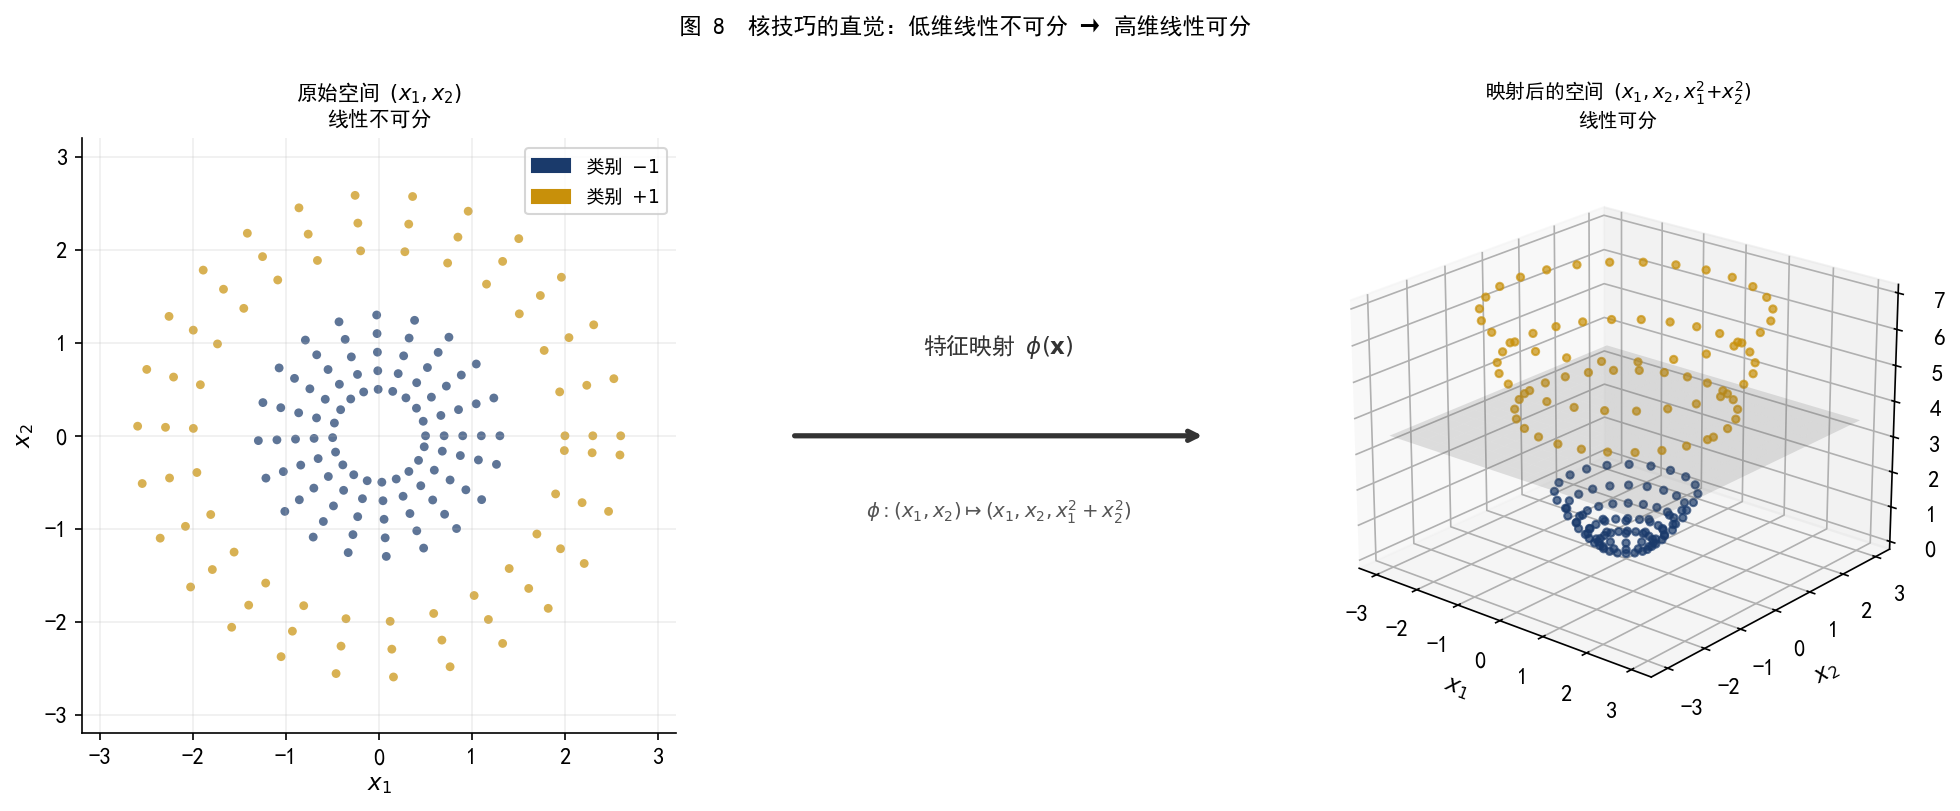

In [12]:
# ------------------------------------------------------------
# 图 08：核技巧直觉（低维不可分 → 高维可分）
# ml_SVM_fig08_kernel_idea
# ------------------------------------------------------------

fig = plt.figure(figsize=(13, 5.2))

# --- 左子图：二维空间，线性不可分 ---
ax1 = fig.add_subplot(1, 3, 1)
# 用简化版：一维问题映射到二维
x_1d = np.linspace(-2.5, 2.5, 300)
# 内圈（蓝）半径 < 1.5
theta_demo = np.linspace(0, 2*np.pi, 80)
r_inner_d = np.r_[0.5, 0.7, 0.9, 1.1, 1.3]
for r in r_inner_d:
    ax1.scatter(r*np.cos(theta_demo[::4]), r*np.sin(theta_demo[::4]),
                c=C_BLUE, s=18, alpha=0.7, edgecolors='none')
r_outer_d = np.r_[2.0, 2.3, 2.6]
for r in r_outer_d:
    ax1.scatter(r*np.cos(theta_demo[::3]), r*np.sin(theta_demo[::3]),
                c=C_YELLOW, s=18, alpha=0.7, edgecolors='none')
ax1.set_xlim(-3.2, 3.2); ax1.set_ylim(-3.2, 3.2)
ax1.set_aspect('equal')
ax1.set_title('原始空间 $(x_1, x_2)$\n线性不可分', fontsize=10)
ax1.set_xlabel('$x_1$'); ax1.set_ylabel('$x_2$')
patches = [mpatches.Patch(color=C_BLUE, label='类别 $-1$'),
           mpatches.Patch(color=C_YELLOW, label='类别 $+1$')]
ax1.legend(handles=patches, fontsize=9, loc='upper right')

# --- 中间：变换箭头 ---
ax2 = fig.add_subplot(1, 3, 2)
ax2.axis('off')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.5),
             arrowprops=dict(arrowstyle='->', color='#333333', lw=2.5))
ax2.text(0.5, 0.62, '特征映射 $\\phi(\\mathbf{x})$',
         ha='center', fontsize=11, color='#333333')
ax2.text(0.5, 0.38, r'$\phi: (x_1,x_2) \mapsto (x_1,x_2,x_1^2+x_2^2)$',
         ha='center', fontsize=9.5, color='#555555')

# --- 右子图：三维空间，线性可分 ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# 内圈点：z = r^2 小（在下方）
for r in r_inner_d:
    pts_x = r*np.cos(theta_demo[::4])
    pts_y = r*np.sin(theta_demo[::4])
    pts_z = pts_x**2 + pts_y**2
    ax3.scatter(pts_x, pts_y, pts_z, c=C_BLUE, s=12, alpha=0.7)
for r in r_outer_d:
    pts_x = r*np.cos(theta_demo[::3])
    pts_y = r*np.sin(theta_demo[::3])
    pts_z = pts_x**2 + pts_y**2
    ax3.scatter(pts_x, pts_y, pts_z, c=C_YELLOW, s=12, alpha=0.7)

# 分割平面：z = 3.5（阈值）
xx3, yy3 = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))
ax3.plot_surface(xx3, yy3, np.full_like(xx3, 3.5),
                 alpha=0.18, color='gray')
ax3.set_title('映射后的空间 $(x_1,x_2,x_1^2{+}x_2^2)$\n线性可分', fontsize=9.5)
ax3.set_xlabel('$x_1$'); ax3.set_ylabel('$x_2$'); ax3.set_zlabel('$x_1^2+x_2^2$')
ax3.view_init(elev=22, azim=-50)

fig.suptitle('图 8  核技巧的直觉：低维线性不可分 → 高维线性可分',
             fontsize=11, y=1.01)
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig08_kernel_idea')
plt.show()

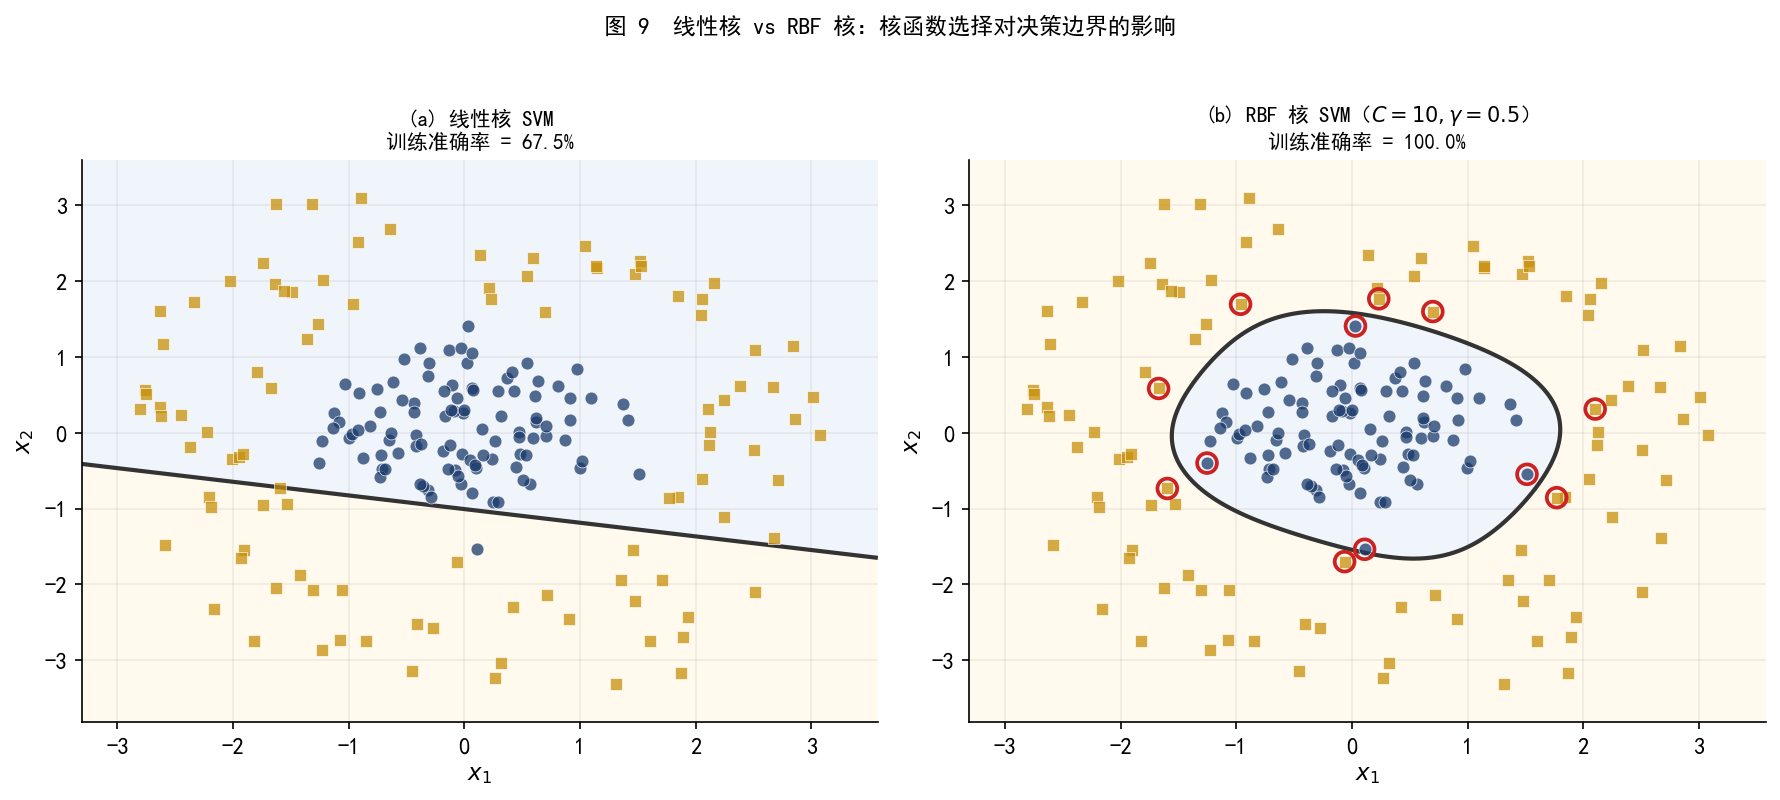

RBF 核训练准确率: 1.0000


In [13]:
# ------------------------------------------------------------
# 图 09：数据集 B，线性核 vs RBF 核
# ml_SVM_fig09_rbf_kernel
# ------------------------------------------------------------

svm_rbf = SVC(kernel='rbf', C=10.0, gamma=0.5)
svm_rbf.fit(X_B, y_B)
acc_rbf = (svm_rbf.predict(X_B) == y_B).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# 左：线性核（重复图07右图用于对比）
ax = axes[0]
plot_decision_boundary(ax, svm_linear_B, X_B, draw_margin=False)
plot_scatter(ax, X_B, y_B)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(f'(a) 线性核 SVM\n训练准确率 = {acc_linear:.1%}', fontsize=10)

# 右：RBF 核
ax = axes[1]
plot_decision_boundary(ax, svm_rbf, X_B, draw_margin=False)
plot_scatter(ax, X_B, y_B)
mark_support_vectors(ax, svm_rbf, s=90)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(f'(b) RBF 核 SVM（$C=10, \\gamma=0.5$）\n训练准确率 = {acc_rbf:.1%}',
             fontsize=10)

fig.suptitle('图 9  线性核 vs RBF 核：核函数选择对决策边界的影响',
             fontsize=11, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig09_rbf_kernel')
plt.show()
print(f'RBF 核训练准确率: {acc_rbf:.4f}')

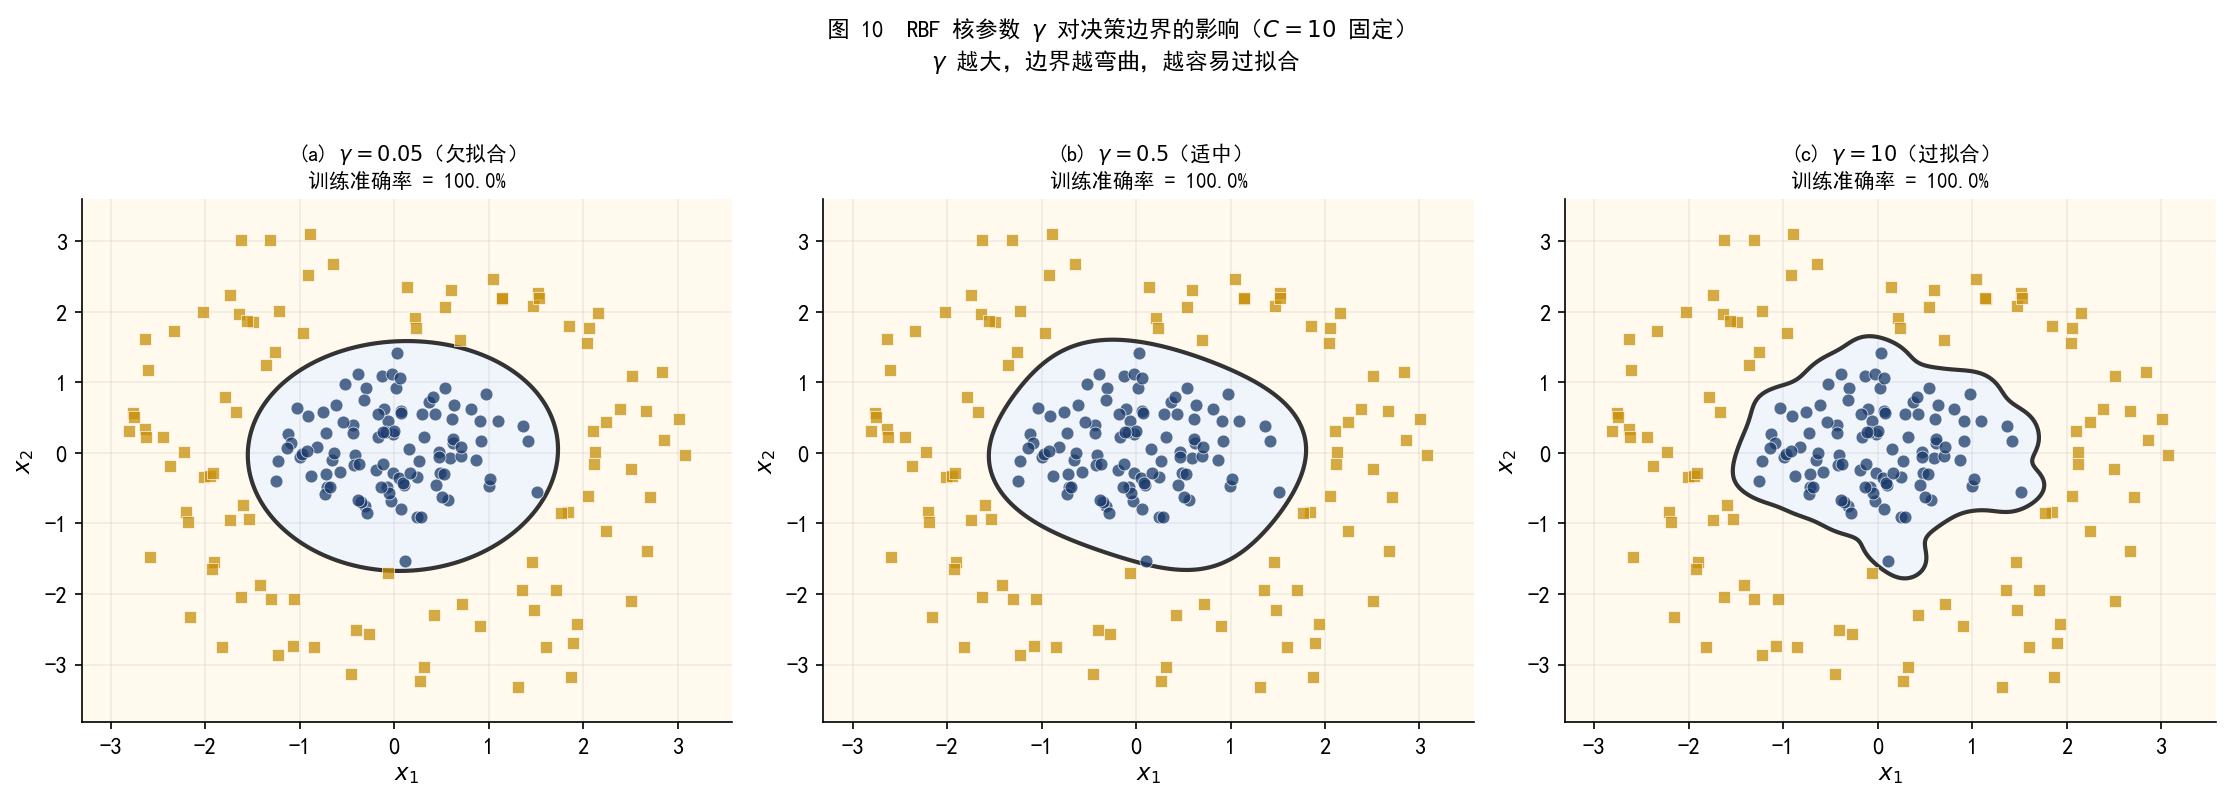

In [14]:
# ------------------------------------------------------------
# 图 10：RBF 核不同 gamma 值（欠拟合/适中/过拟合）
# ml_SVM_fig10_gamma_compare
# ------------------------------------------------------------

gamma_vals = [0.05, 0.5, 10.0]
titles_g = [
    '(a) $\\gamma = 0.05$（欠拟合）',
    '(b) $\\gamma = 0.5$（适中）',
    '(c) $\\gamma = 10$（过拟合）',
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))

for ax, gamma, title in zip(axes, gamma_vals, titles_g):
    clf = SVC(kernel='rbf', C=10.0, gamma=gamma)
    clf.fit(X_B, y_B)
    acc = (clf.predict(X_B) == y_B).mean()

    plot_decision_boundary(ax, clf, X_B, draw_margin=False)
    plot_scatter(ax, X_B, y_B)
    ax.set_title(f'{title}\n训练准确率 = {acc:.1%}', fontsize=10)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

fig.suptitle('图 10  RBF 核参数 $\\gamma$ 对决策边界的影响（$C=10$ 固定）\n'
             '$\\gamma$ 越大，边界越弯曲，越容易过拟合',
             fontsize=11, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig10_gamma_compare')
plt.show()

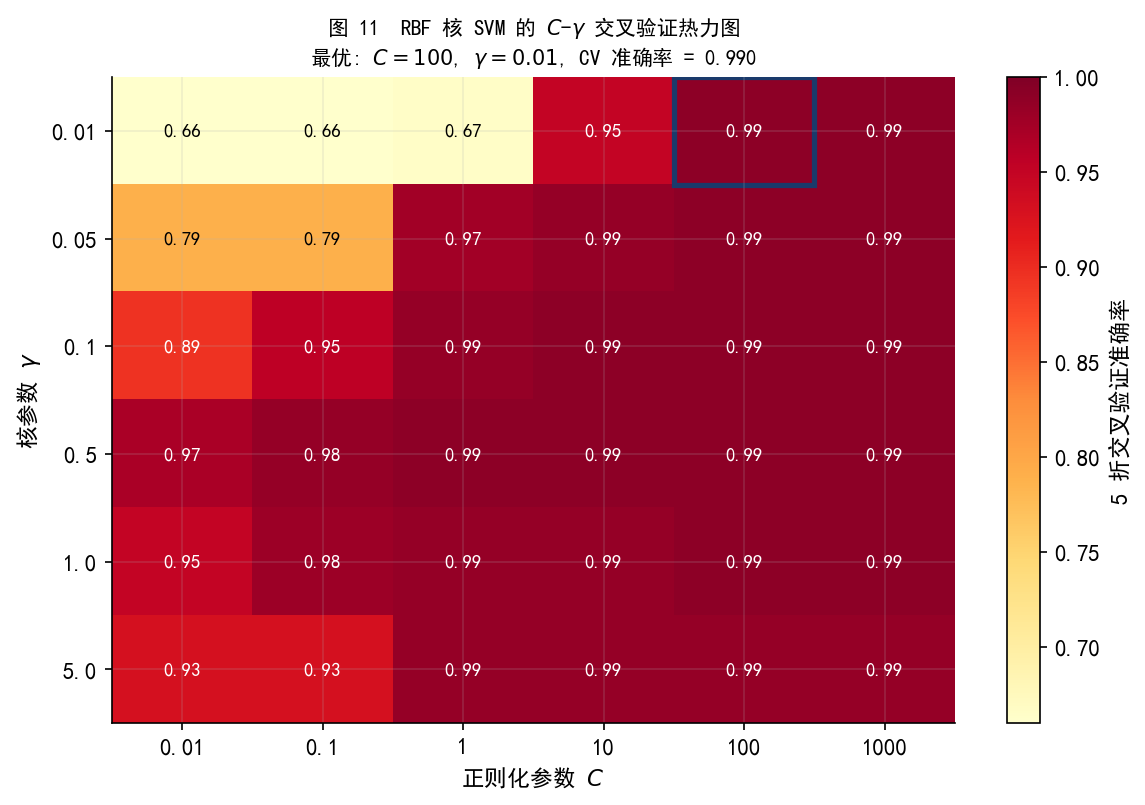

最优 C=100, gamma=0.01, CV=0.9900


In [15]:
# ------------------------------------------------------------
# 图 11：C-gamma 网格搜索热力图
# ml_SVM_fig11_C_gamma_heatmap
# ------------------------------------------------------------

from sklearn.model_selection import cross_val_score

C_range     = [0.01, 0.1, 1, 10, 100, 1000]
gamma_range = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]

cv_scores = np.zeros((len(gamma_range), len(C_range)))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i, gamma in enumerate(gamma_range):
    for j, C in enumerate(C_range):
        clf = SVC(kernel='rbf', C=C, gamma=gamma)
        scores = cross_val_score(clf, X_B, y_B, cv=cv, scoring='accuracy')
        cv_scores[i, j] = scores.mean()

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(cv_scores, cmap='YlOrRd', aspect='auto',
               vmin=cv_scores.min(), vmax=1.0)
plt.colorbar(im, ax=ax, label='5 折交叉验证准确率')

ax.set_xticks(range(len(C_range)))
ax.set_xticklabels([str(c) for c in C_range])
ax.set_yticks(range(len(gamma_range)))
ax.set_yticklabels([str(g) for g in gamma_range])
ax.set_xlabel('正则化参数 $C$')
ax.set_ylabel('核参数 $\\gamma$')

# 标注每个格子的数值
for i in range(len(gamma_range)):
    for j in range(len(C_range)):
        val = cv_scores[i, j]
        color = 'white' if val > 0.85 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

# 标出最优参数
best_i, best_j = np.unravel_index(cv_scores.argmax(), cv_scores.shape)
ax.add_patch(plt.Rectangle((best_j-0.5, best_i-0.5), 1, 1,
                            fill=False, edgecolor='#1A3A6B', lw=2.5))

ax.set_title(f'图 11  RBF 核 SVM 的 $C$-$\\gamma$ 交叉验证热力图\n'
             f'最优: $C={C_range[best_j]}$, $\\gamma={gamma_range[best_i]}$, '
             f'CV 准确率 = {cv_scores[best_i, best_j]:.3f}',
             fontsize=10)
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig11_C_gamma_heatmap')
plt.show()
print(f'最优 C={C_range[best_j]}, gamma={gamma_range[best_i]}, CV={cv_scores[best_i,best_j]:.4f}')

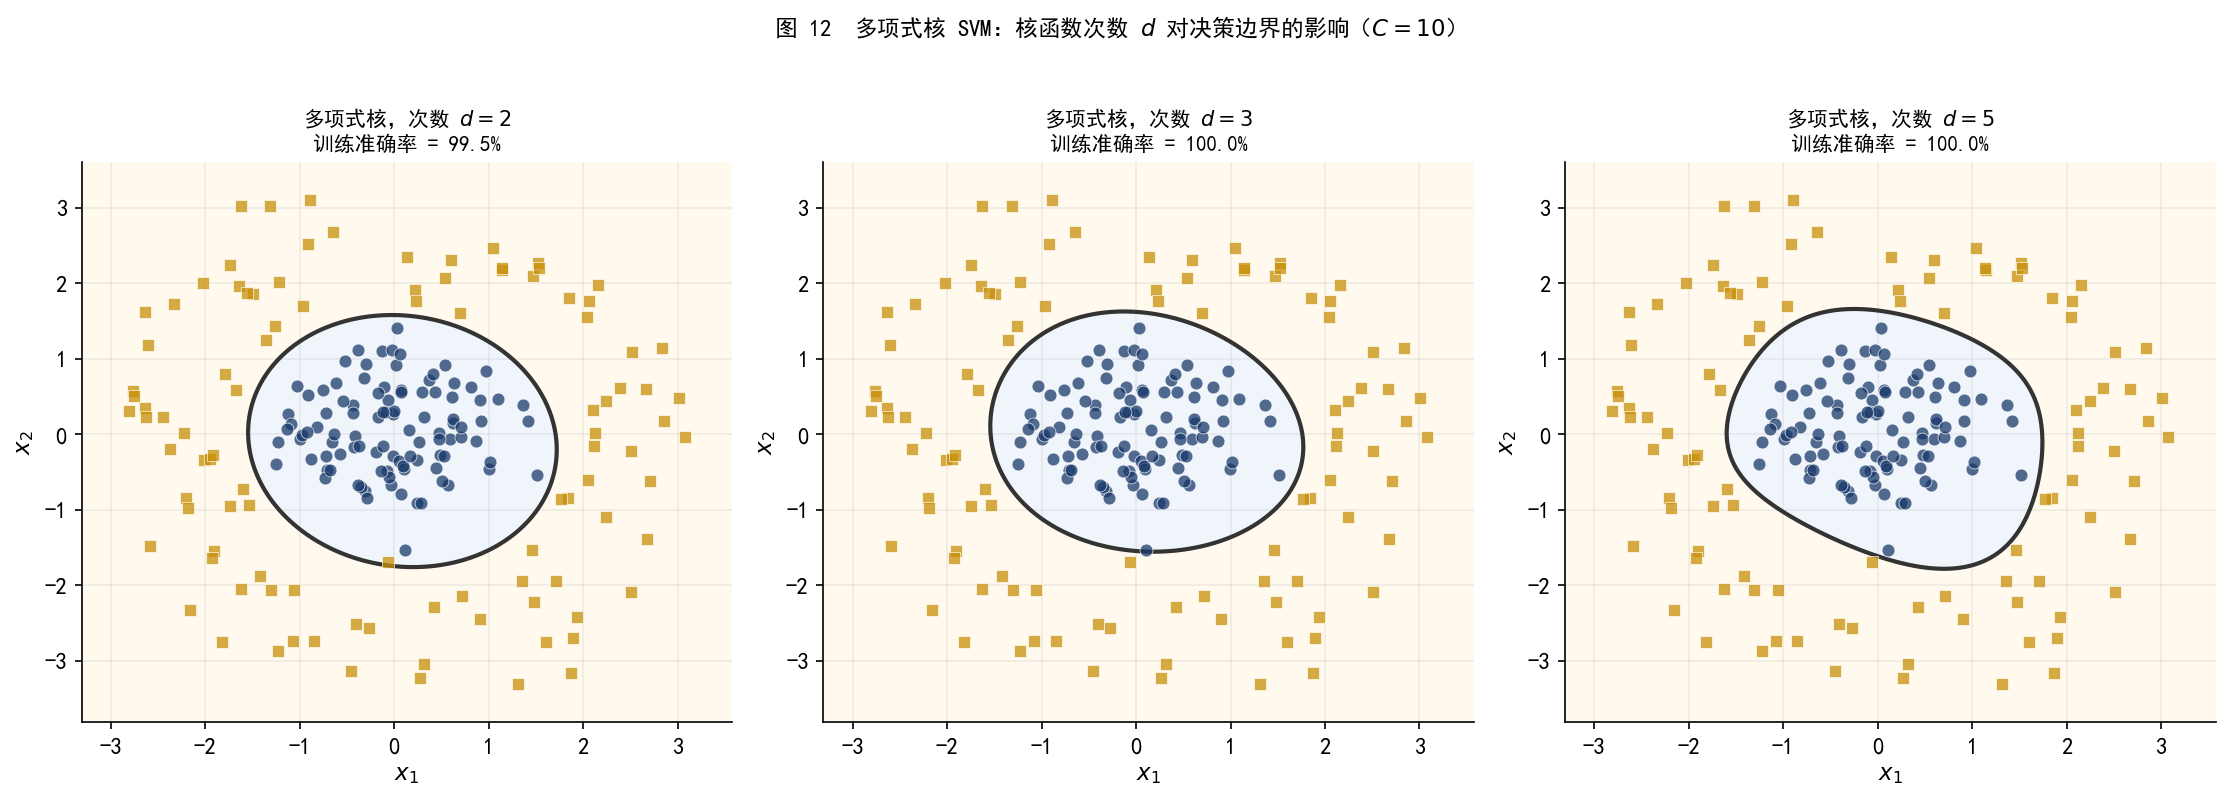

In [16]:
# ------------------------------------------------------------
# 图 12：多项式核 SVM
# ml_SVM_fig12_poly_kernel
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))

degrees = [2, 3, 5]
for ax, d in zip(axes, degrees):
    clf_poly = SVC(kernel='poly', degree=d, C=10.0, coef0=1.0)
    clf_poly.fit(X_B, y_B)
    acc = (clf_poly.predict(X_B) == y_B).mean()

    plot_decision_boundary(ax, clf_poly, X_B, draw_margin=False)
    plot_scatter(ax, X_B, y_B)
    ax.set_title(f'多项式核，次数 $d={d}$\n训练准确率 = {acc:.1%}', fontsize=10)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

fig.suptitle('图 12  多项式核 SVM：核函数次数 $d$ 对决策边界的影响（$C=10$）',
             fontsize=11, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig12_poly_kernel')
plt.show()

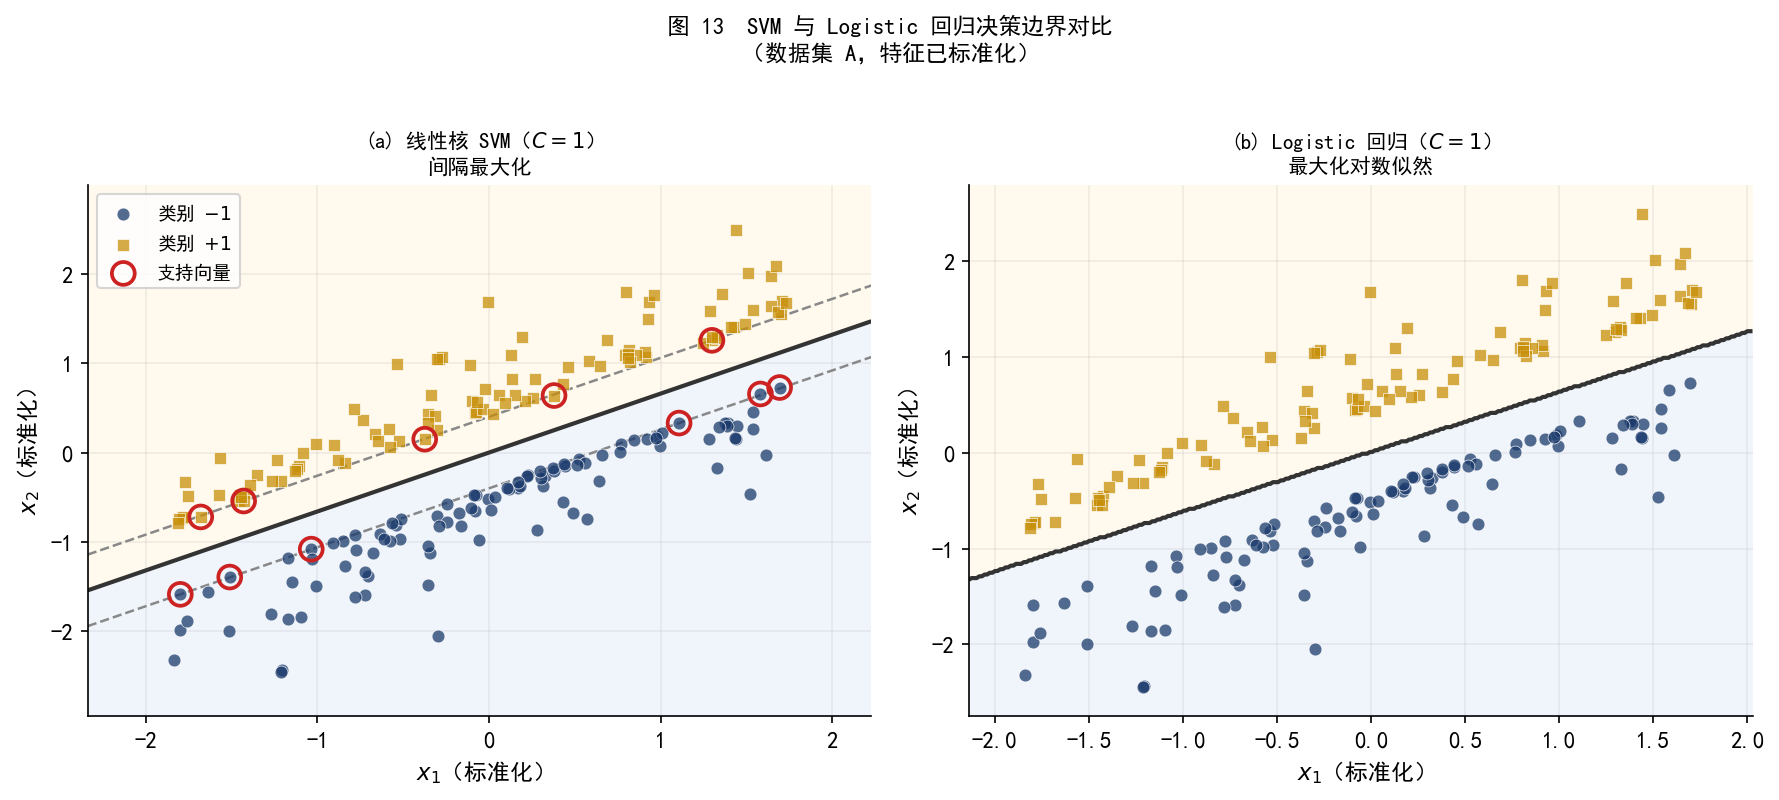

In [17]:
# ------------------------------------------------------------
# 图 13：SVM 与 Logistic 回归决策边界对比
# ml_SVM_fig13_svm_vs_logistic
# ------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_A_sc = scaler.fit_transform(X_A)

svm_compare   = SVC(kernel='linear', C=1.0)
logit_compare = LogisticRegression(C=1.0, max_iter=1000)

svm_compare.fit(X_A_sc, y_A)
logit_compare.fit(X_A_sc, y_A)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# SVM
ax = axes[0]
plot_decision_boundary(ax, svm_compare, X_A_sc, draw_margin=True)
plot_scatter(ax, X_A_sc, y_A)
mark_support_vectors(ax, svm_compare)
ax.set_xlabel('$x_1$（标准化）'); ax.set_ylabel('$x_2$（标准化）')
ax.set_title('(a) 线性核 SVM（$C=1$）\n间隔最大化', fontsize=10)
ax.legend(fontsize=9)

# Logistic 回归
ax = axes[1]
# 手动画 Logistic 决策边界
x_min, x_max = X_A_sc[:,0].min()-0.3, X_A_sc[:,0].max()+0.3
y_min, y_max = X_A_sc[:,1].min()-0.3, X_A_sc[:,1].max()+0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))
Z_log = logit_compare.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
bg_cmap = ListedColormap(['#D6E4F7', '#FFF3CC'])
ax.contourf(xx, yy, Z_log, levels=[-1.5, 0, 1.5],
            cmap=bg_cmap, alpha=0.35, zorder=0)
ax.contour(xx, yy, Z_log, levels=[0.5],
           colors='#333333', linewidths=2.0, zorder=2)
plot_scatter(ax, X_A_sc, y_A)
ax.set_xlabel('$x_1$（标准化）'); ax.set_ylabel('$x_2$（标准化）')
ax.set_title('(b) Logistic 回归（$C=1$）\n最大化对数似然', fontsize=10)

fig.suptitle('图 13  SVM 与 Logistic 回归决策边界对比\n'
             '（数据集 A，特征已标准化）',
             fontsize=11, y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_SVM_fig13_svm_vs_logistic')
plt.show()